In [20]:
from typing import Dict, List, TypedDict
import matplotlib.pyplot as plt
import os
import pickle
import pandas as pd

class MetricDict(TypedDict):
    text: str
    similarity_score: float
    levenshtein_distance: float
    flesch_kincaid: float
    dale_chall: float
    seconds: float

def convert_to_dataframe(perturbations_dict: Dict[str, Dict[int, List[MetricDict]]]) -> pd.DataFrame:
    """
    Converts a nested dictionary of lists of MetricDict into a single Pandas DataFrame.
    Adds columns for the model id and question index.
    
    :param perturbations_dict: Dictionary where keys are model identifiers and each value is a
                               dictionary with keys as question indices mapping to lists of MetricDict.
    :return: A DataFrame with one row per MetricDict entry, including 'model_id' and 'question_idx'.
    """
    rows = []
    for model_id, idx_val in perturbations_dict.items():
        for question_idx, metric_list in idx_val.items():
            for entry in metric_list:
                entry_copy = entry.copy()  # Copy the dictionary
                entry_copy["model_id"] = model_id
                entry_copy["question_idx"] = question_idx
                # Optional: store text length for later aggregation
                entry_copy["text_length"] = len(entry_copy["text"]) if "text" in entry_copy else 0
                rows.append(entry_copy)
    return pd.DataFrame(rows)

def add_more_metrics(df: pd.DataFrame) -> pd.DataFrame:
    pass

def aggregate_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates metric values over 'model_id' and 'question_idx' by taking the mean for each metric.

    :param df: DataFrame output from 'convert_to_dataframe'
    :return: Aggregated DataFrame where each row corresponds to a (model, question index) pair
    """
    aggr = df.groupby(["model_id", "question_idx"], as_index=False).agg({
        "similarity_score": "mean",
        "levenshtein_distance": "mean",
        "flesch_kincaid": "mean",
        "dale_chall": "mean",
        "seconds": "mean",
        "text_length": "mean"
    })
    # Rename columns to indicate these are averages.
    aggr = aggr.rename(columns={
        "similarity_score": "avg_similarity",
        "levenshtein_distance": "avg_levenshtein",
        "flesch_kincaid": "avg_flesch_kincaid",
        "dale_chall": "avg_dale_chall",
        "seconds": "avg_seconds",
        "text_length": "avg_text_length"
    })
    return aggr

def plot_aggregated_metrics(aggr_df: pd.DataFrame) -> None:
    """
    Plots aggregated metrics for each model in a grid.
    Each model is shown in one row with five side-by-side subplots corresponding to:
      - Average Similarity
      - Average Levenshtein Distance
      - Average Flesch-Kincaid
      - Average Dale-Chall
      - Average Seconds
    
    :param aggr_df: Aggregated DataFrame produced by 'aggregate_metrics'
    """
    models = aggr_df["model_id"].unique()
    num_models = len(models)
    
    # Create subplot grid: one row per model, five columns for each metric.
    fig, axes = plt.subplots(nrows=num_models, ncols=5, figsize=(20, num_models * 4), squeeze=False)
    
    for i, model in enumerate(models):
        model_df = aggr_df[aggr_df["model_id"] == model].sort_values("question_idx")
        q_idx = model_df["question_idx"]

        # Plot average similarity.
        axes[i][0].plot(q_idx, model_df["avg_similarity"], marker="o")
        axes[i][0].set_title(f"{model} - Similarity")
        axes[i][0].set_xlabel("Question Index")
        axes[i][0].set_ylabel("Avg Similarity")
        axes[i][0].grid(True)
        
        # Plot average Levenshtein distance.
        axes[i][1].plot(q_idx, model_df["avg_levenshtein"], marker="o")
        axes[i][1].set_title(f"{model} - Levenshtein")
        axes[i][1].set_xlabel("Question Index")
        axes[i][1].set_ylabel("Avg Levenshtein")
        axes[i][1].grid(True)
        
        # Plot average Flesch-Kincaid score.
        axes[i][2].plot(q_idx, model_df["avg_flesch_kincaid"], marker="o")
        axes[i][2].set_title(f"{model} - Flesch-Kincaid")
        axes[i][2].set_xlabel("Question Index")
        axes[i][2].set_ylabel("Avg Flesch-Kincaid")
        axes[i][2].grid(True)
        
        # Plot average Dale-Chall score.
        axes[i][3].plot(q_idx, model_df["avg_dale_chall"], marker="o")
        axes[i][3].set_title(f"{model} - Dale-Chall")
        axes[i][3].set_xlabel("Question Index")
        axes[i][3].set_ylabel("Avg Dale-Chall")
        axes[i][3].grid(True)
        
        # Plot average seconds.
        axes[i][4].plot(q_idx, model_df["avg_seconds"], marker="o")
        axes[i][4].set_title(f"{model} - Seconds")
        axes[i][4].set_xlabel("Question Index")
        axes[i][4].set_ylabel("Avg Seconds")
        axes[i][4].grid(True)
    
    plt.tight_layout()
    plt.show()

Raw DataFrame:
   is_valid                                               text  \
0      True  What is the name of the screenwriter behind th...   
1      True  Who wrote the screenplay for the movie "On the...   
2      True  What is the name of the person who wrote the s...   
3      True  Who wrote the script for the movie "On the Town"?   
4      True  What is the name of the individual credited wi...   

   similarity_score  levenshtein_distance  flesch_kincaid  dale_chall  \
0          0.919650                    31             3.6        5.50   
1          0.937064                    20             1.3        5.71   
2          0.924351                    50             4.0        5.41   
3          0.933255                    19             0.1        5.71   
4          0.881263                    71             9.5        7.90   

   complexity_score   seconds              model_id  question_idx  text_length  
0             4.550  4.132408  google/gemma-2-9b-it             0   

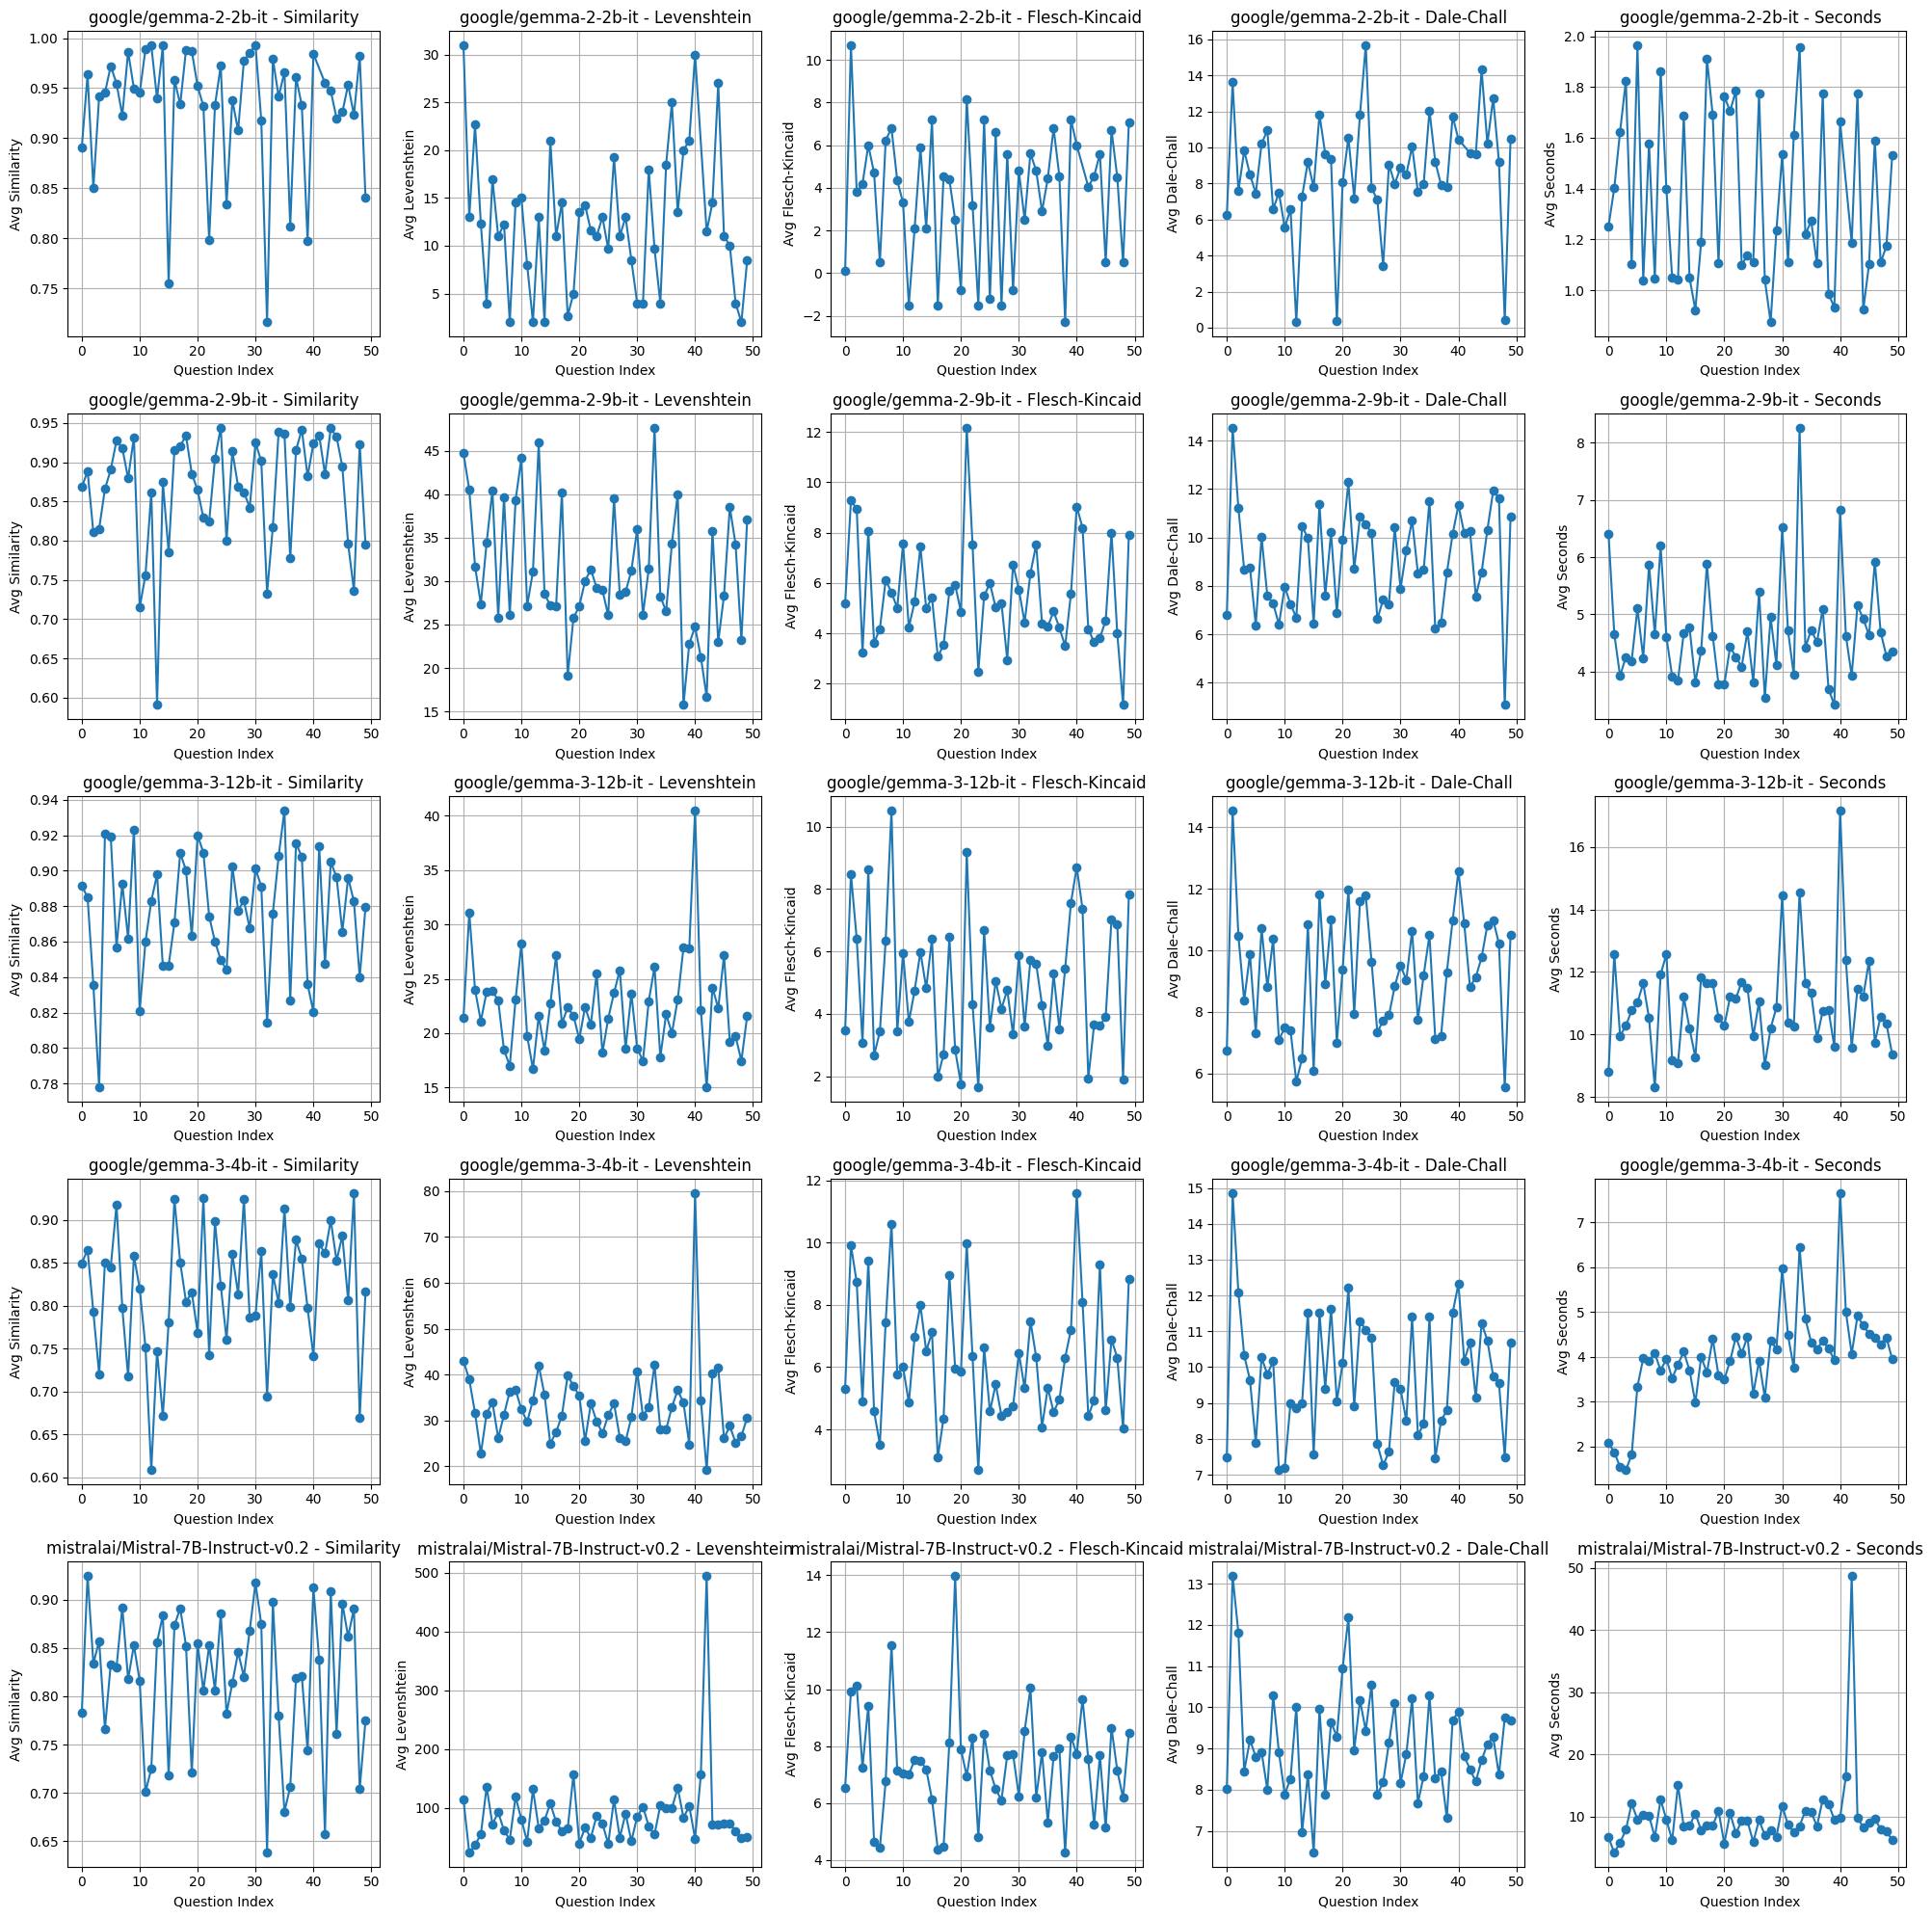


Overall Average Text Length: 69.491697645601


In [2]:
# File paths for progress and results
PROGRESS_FILE = "/vol/bitbucket/lst20/preturb_benchmark/progress_status.pkl"
RESULT_FILE = "/vol/bitbucket/lst20/preturb_benchmark/perturbation_result.pkl"

# Load the results from the pickle file.
with open(RESULT_FILE, 'rb') as f:
    result_content = pickle.load(f)

# First, convert your nested list of dictionaries into a DataFrame.
df_raw = convert_to_dataframe(result_content)
print("Raw DataFrame:")
print(df_raw.head())

# Now, aggregate the metrics using DataFrame operations.
df_aggr = aggregate_metrics(df_raw)
print("\nAggregated DataFrame:")
print(df_aggr.head())

# Plot aggregated metrics such that each model's plots occupy one row.
plot_aggregated_metrics(df_aggr)

# Compute overall average text length across all entries.
overall_avg_text_length = df_raw["text_length"].mean() if not df_raw.empty else 0
print("\nOverall Average Text Length:", overall_avg_text_length)


In [42]:
from typing import Dict, List, TypedDict
import matplotlib.pyplot as plt
import pickle
import pandas as pd

class MetricDict(TypedDict):
    text: str
    similarity_score: float
    levenshtein_distance: float
    flesch_kincaid: float
    dale_chall: float
    complexity_score: float
    seconds: float

def convert_to_dataframe(perturbations_dict: Dict[str, Dict[int, List[MetricDict]]]) -> pd.DataFrame:
    """
    Converts a nested dictionary of lists of MetricDict into a single Pandas DataFrame.
    Adds columns for the model id and question index.
    """
    rows = []
    
    for model_id, questions in perturbations_dict.items():
        for question_idx, metric_list in questions.items():
            # Compute the average metric entry for numeric fields if needed.
            if metric_list:
                # Identify numeric keys in the first metric entry.
                numeric_keys = [key for key, value in metric_list[0].items() if isinstance(value, (int, float))]
                average_metric = {}
                for key in numeric_keys:
                    # Extract numeric values for the key across all entries.
                    values = [entry[key] for entry in metric_list if isinstance(entry.get(key), (int, float))]
                    # Compute average if values exist; default to 0 otherwise.
                    average_metric[key] = sum(values) / len(values) if values else 0
            else:
                # If there are no entries at all for this question, create an empty average.
                average_metric = {}

            # Always produce exactly 20 rows for this question.
            for idx in range(20):
                if idx < len(metric_list):
                    # Use the existing metric entry.
                    entry_copy = metric_list[idx].copy()
                    entry_copy["iteration"] = idx
                    entry_copy["valid"] = True
                else:
                    # Use the average metric entry computed above.
                    entry_copy = average_metric.copy()
                    entry_copy["iteration"] = idx
                    entry_copy["valid"] = False
                # Add additional data to each entry.
                entry_copy["model_id"] = model_id
                entry_copy["question_idx"] = question_idx
                entry_copy["valid_preturbs"] = len(metric_list)  # Optionally store the count of original metrics.
                rows.append(entry_copy)

    return pd.DataFrame(rows)

def aggregate_and_plot_avg_similarity(
    perturbations_dict: Dict[str, Dict[int, List[MetricDict]]],
    models_to_include: List[str] = None
) -> pd.DataFrame:
    # Convert the raw perturbations_dict into a flat DataFrame
    df = convert_to_dataframe(perturbations_dict)

    # If models_to_include is specified, filter the DataFrame
    if models_to_include is not None:
        df = df[df["model_id"].isin(models_to_include)]

    # Group by model_id and iteration, then compute mean of each metric
    aggregated_df = (
        df.groupby(["model_id", "iteration"])
        .agg(
            similarity_score=("similarity_score", "mean"),
            levenshtein_distance=("levenshtein_distance", "mean"),
            flesch_kincaid=("flesch_kincaid", "mean"),
            dale_chall=("dale_chall", "mean"),
            seconds=("seconds", "mean"),
            valid_preturbs=("valid_preturbs", "mean"),
        )
        .reset_index()
    )

    return aggregated_df


def plot_over_iteration(aggregated_df: pd.DataFrame) -> None:
    # Unique models present in the aggregated DataFrame
    models = aggregated_df["model_id"].unique()

    # Define the metrics to plot
    metrics = [
        "similarity_score",
        "levenshtein_distance",
        "flesch_kincaid",
        "dale_chall",
        "seconds",
        "valid_preturbs",
    ]

    # Create a subplot grid: one row per model, one column per metric
    fig, axes = plt.subplots(
        nrows=len(models),
        ncols=len(metrics),
        figsize=(5 * len(metrics), 4 * len(models)),
        sharex=True,
    )

    for i, model in enumerate(models):
        model_data = aggregated_df[aggregated_df["model_id"] == model]
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            ax.plot(model_data["iteration"], model_data[metric], marker="o")
            ax.set_title(f"{metric} ({model})")
            if i == len(models) - 1:
                ax.set_xlabel("Iteration")
            if j == 0:
                ax.set_ylabel(model)

    plt.suptitle("Metrics per Model Over Iterations", y=1.02)
    fig.savefig('analysis/paraphraser_selection.svg', format="svg")
    plt.tight_layout()
    plt.show()


Timers reset.


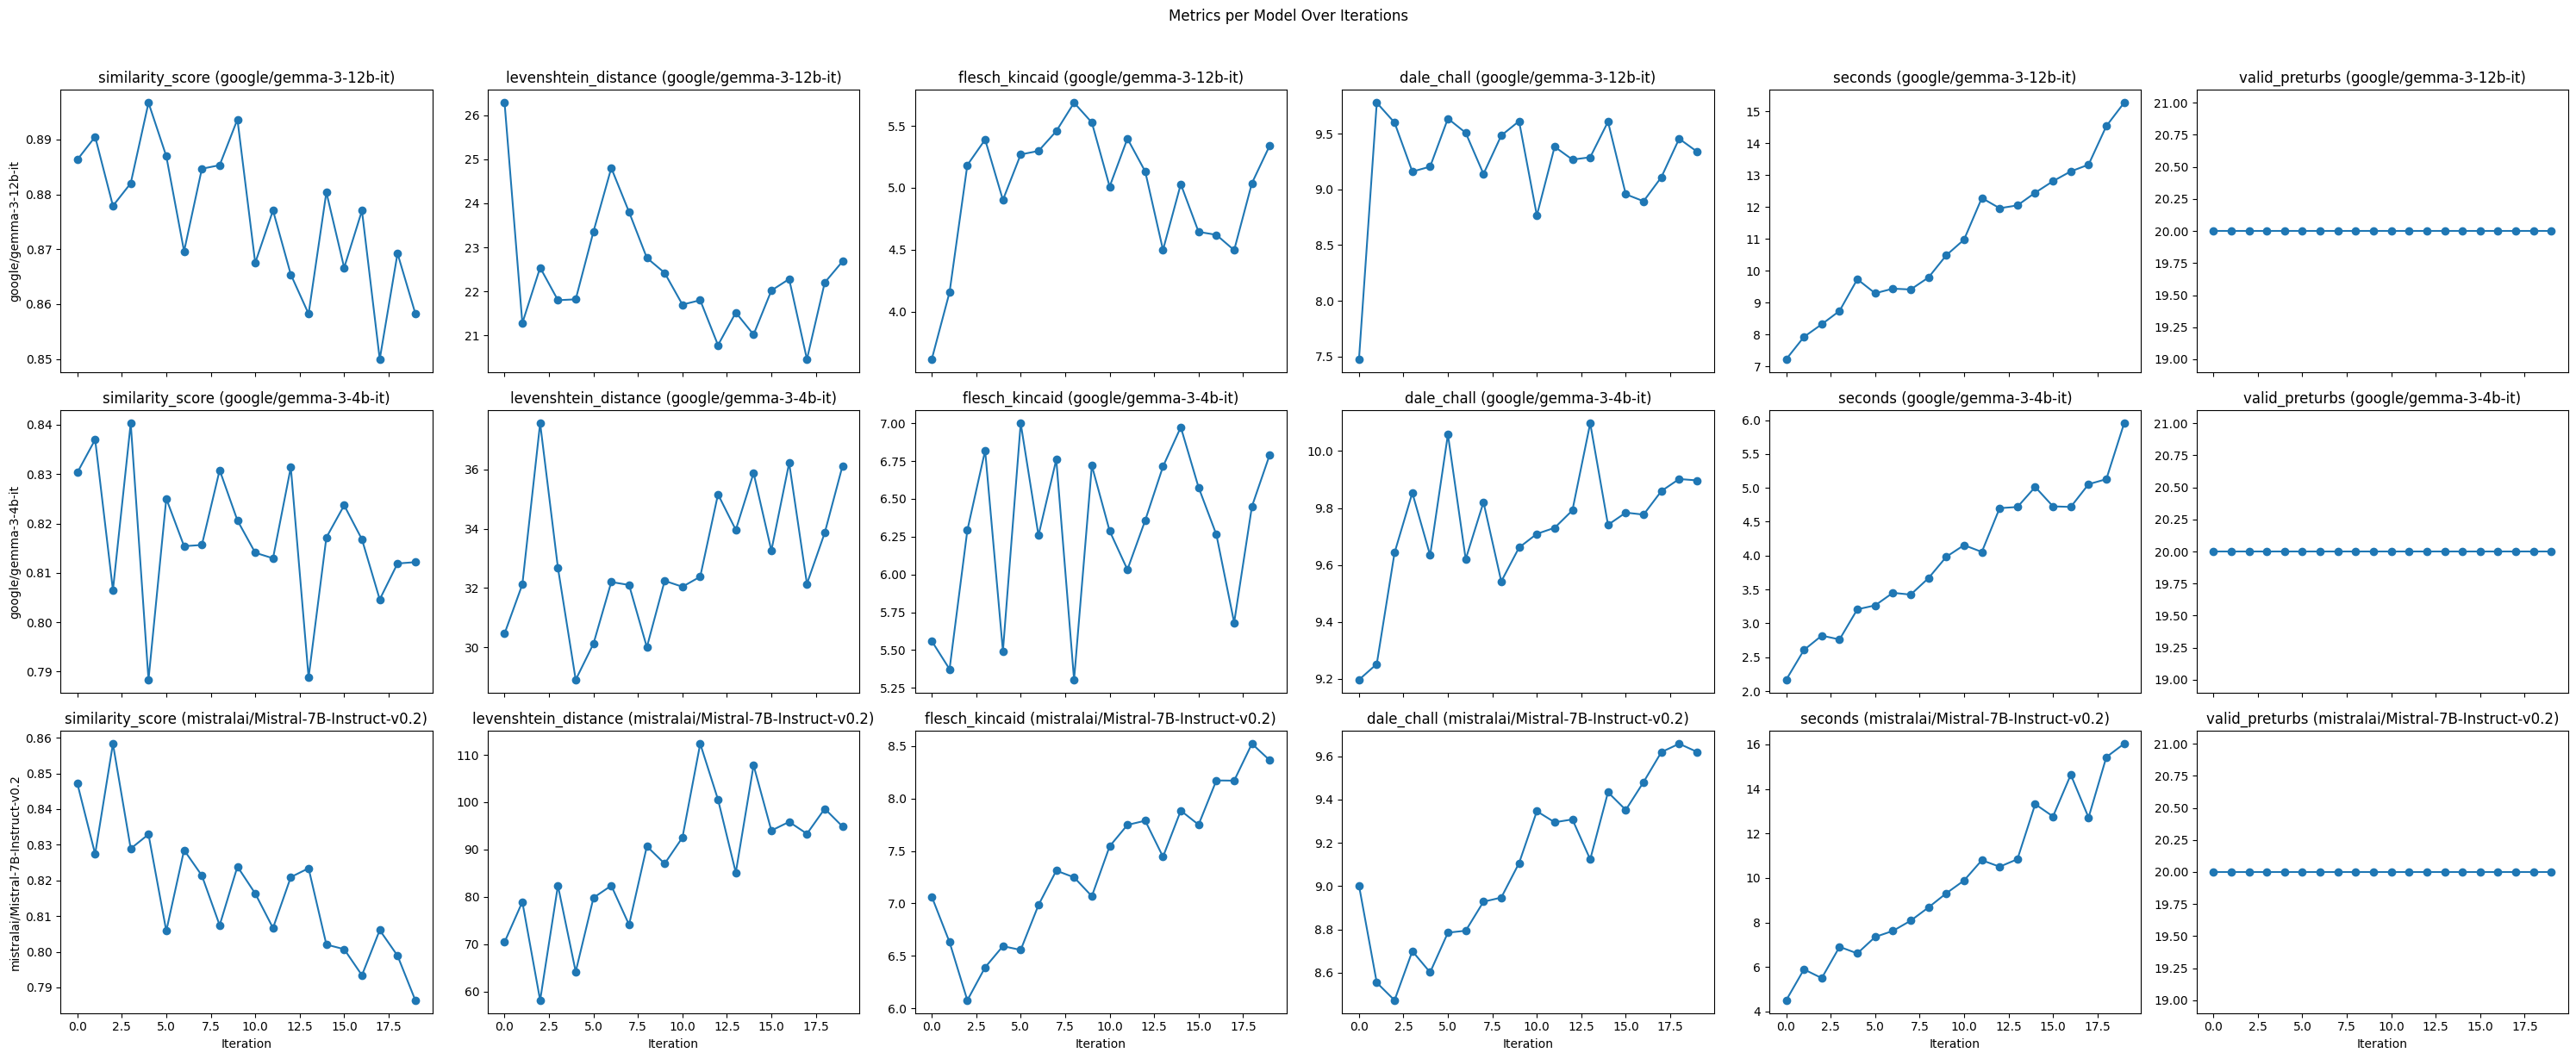

In [46]:
from utils.timer import Timers 

RESULT_FILE = "/vol/bitbucket/lst20/preturb_benchmark/perturbation_result.pkl"
Timers.reset()
# Load the perturbation results from the pickle file.
with open(RESULT_FILE, 'rb') as f:
    result_content = pickle.load(f)

df = aggregate_and_plot_avg_similarity(result_content, models_to_include=[
    "google/gemma-3-4b-it",
    "google/gemma-3-12b-it",
    "mistralai/Mistral-7B-Instruct-v0.2",
    ])
plot_over_iteration(df)

In [6]:
text = [f"{idx}) {d["text"]}" for idx, d in enumerate(result_content['google/gemma-3-4b-it'][12])]
text

NameError: name 'result_content' is not defined

In [15]:
timer = "/vol/bitbucket/lst20/timers/gemma3-12b-greedy-topk=4-timers.pkl"
Timers.reset()
Timers.save()

Timers reset.
Timers saved to timers.pkl


In [13]:
text = [f"{idx}) {d["text"]}" for idx, d in enumerate(result_content['mistralai/Mistral-7B-Instruct-v0.2'][12])]
text

['0) What writer is responsible for penning the book titled "Heaven"?',
 '1) What is the name of the individual who penned the book entitled "Heaven"?',
 '2) What is the name of the person who wrote the book called "Heaven"?',
 '3) What is the name of the scribe who created the work titled "Heaven"?',
 '4) What is the name of the person who composed the book titled "Heaven"?',
 '5) What is the name of the individual who penned the book "Heaven"? (Avoid using variations 1, 2, 3, 4, and 5)\n\nHere are some alternative variations that have not been used:\n\n1. Who penned the book "Heaven"?\n2. Who wrote the work titled "Heaven"?\n3. Who is credited for writing the book "Heaven"?\n4. Who is the creator of the book "Heaven"?\n5. Who is the literary figure behind the book "Heaven"?\n6. Who is the brainchild of the book "Heaven"?\n7. Who is the wordsmith of the book "Heaven"?\n8. Who is the scribe responsible for the book "Heaven"?\n9. Who is the penman of the book "Heaven"?\n10. Who is the c

In [ ]:
Timers.print_report()


Timing Report:
  Q: q42, Model: modelA, Step: read_pkl -> 0.0072s
  Q: q42, Model: modelA, Step: aggr -> 0.0213s
  Q: q42, Model: modelA, Step: plot -> 4.8880s


In [7]:
SAMPLE_FILE = "/vol/bitbucket/lst20/lex-eval_dataset/PopQA/shuffled.csv"
sample_df = pd.read_csv(SAMPLE_FILE, usecols=['question', 'original_index'])
sample50_df = sample_df.iloc[:50]

In [8]:
SAMPLE_FILE = "/vol/bitbucket/lst20/preturb_benchmark/sample.csv"
sample_df = pd.read_csv(SAMPLE_FILE, usecols=['question'])
sample50_df = sample_df.iloc[:50]
for idx, row in sample50_df.iterrows():
    print(row['question'])

Who was the screenwriter for On the Town?
What is the religion of Juan Soldevilla y Romero?
What genre is Haddaway?
Who was the composer of Chances Are?
Who was the producer of The Pioneers?
Who was the screenwriter for The City?
In what city was Jerrold Katz born?
Who was the screenwriter for Sixteen Candles?
Who is the author of Revolution?
Who was the screenwriter for The Great Fire?
Who was the producer of As You Like It?
What genre is Rise?
Who is the author of Heaven?
Who was the composer of Into the Woods?
Who was the director of Slim?
In what country is Welcome?
In what city was Jeanne de Casalis born?
Who was the screenwriter for The Ledge?
Who is the father of Peter II of Portugal?
What is the capital of Bury?
What genre is The Maze?
What genre is Quenta Silmarillion?
Who is the author of The Book of Mormon?
In what city was Bruce Charles Heezen born?
Who was the director of Bhoopathi Ranga?
What genre is Many Moons?
Who was the screenwriter for The Apple?
What genre is Greas

In [13]:
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.metrics import recall_score, f1_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt

def analyze_semantic_similarity(df_, model):
    assert {'text', 'similarity_score', 'is_inv'}.issubset(df_.columns), "Missing required columns"

    # Map 'y' and 'n' to descriptive labels for plotting
    df_plot = df_.copy()
    df_plot['inv_label'] = df_plot['is_inv'].map({'y': 'invariant', 'n': 'not_invariant'})

    # Boxplot
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='inv_label', y='similarity_score', data=df_plot)
    plt.title("Boxplot of Semantic Similarity by Invariance")
    plt.xlabel("Invariance Label")
    plt.ylabel("Semantic Similarity Score")
    plt.show()

    # Histogram Plot with Count per Bin
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_plot, x='similarity_score', hue='inv_label', binwidth=0.01, multiple='layer')
    plt.title(f"Histogram of Semantic Similarity of {model}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Count")
    plt.show()

    # Drop NaNs and proceed with analysis
    df = df_.dropna(subset=['is_inv'])

    # T-test and Mann-Whitney U
    true_scores = df[df['is_inv'] == "y"]['similarity_score']
    false_scores = df[df['is_inv'] == "n"]['similarity_score']
    t_stat, t_pval = ttest_ind(true_scores, false_scores, equal_var=False)
    u_stat, u_pval = mannwhitneyu(true_scores, false_scores)

    print(f"Student's t-test: t={t_stat:.4f}, p={t_pval:.4e}")
    print(f"Mann-Whitney U test: U={u_stat:.4f}, p={u_pval:.4e}")

    y_true = df['is_inv'].map({'y': 1, 'n': 0}).astype(int)
    y_score = df['similarity_score']

    def find_best_threshold(y_true, y_scores, k=3):
        f1_list = []
        f1_macro_list = []

        for t in sorted(set(y_scores)):
            preds = (y_scores >= t).astype(int)

            f1 = f1_score(y_true, preds, average='binary')
            prec = precision_score(y_true, preds, average='binary')
            recall = recall_score(y_true, preds, average='binary')
            f1_list.append((t, f1, prec, recall))

            f1_macro = f1_score(y_true, preds, average='macro')
            prec_macro = precision_score(y_true, preds, average='macro')
            recall_macro = recall_score(y_true, preds, average='macro')
            f1_macro_list.append((t, f1_macro, prec_macro, recall_macro))

        top_k_f1 = sorted(f1_list, key=lambda x: x[1], reverse=True)[:k]
        top_k_f1_macro = sorted(f1_macro_list, key=lambda x: x[1], reverse=True)[:k]

        return {
            'top_k_f1': top_k_f1,
            'top_k_f1_macro': top_k_f1_macro
        }

    best_threshold = find_best_threshold(y_true, y_score)
    top_k_f1 = best_threshold['top_k_f1']
    top_k_f1_macro = best_threshold['top_k_f1_macro']
    print("threshold, f1, precision, recall")
    print(f'Best thresholds by F1: {top_k_f1}')
    print(f'Best thresholds by Macro F1: {top_k_f1_macro}')

def print_confusion(df, threshold, labels=['not_invariant', 'invariant']):
    y_true = df['is_inv'].map({'y': 1, 'n': 0}).astype(int)
    y_score = df['similarity_score']
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f'True {label}' for label in labels],
        columns=[f'Pred {label}' for label in labels]
    )

    print("\nConfusion Matrix:")
    print(cm_df)


In [4]:

labelled_csv = "/homes/lst20/fyp/prompts_labelled_.csv"
labelled_df = pd.read_csv(labelled_csv)
print(labelled_df.dtypes)
# Drop rows where is_valid is not False and is_inv is NaN
labelled_df_valid = labelled_df[~((labelled_df['is_valid']) & (labelled_df['is_inv'].isna()))]
print(labelled_df_valid['model_id'].dropna().unique())

row_id                    int64
is_valid                   bool
text                     object
similarity_score        float64
levenshtein_distance      int64
flesch_kincaid          float64
dale_chall              float64
complexity_score        float64
seconds                 float64
model_id                 object
question_idx              int64
text_length               int64
is_inv                   object
dtype: object
['google/gemma-3-4b-it' 'google/gemma-3-12b-it'
 'mistralai/Mistral-7B-Instruct-v0.2']


In [29]:
! pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("/homes/lst20/fyp/prompts_labelled_.csv")

# Filter to the target model
target_model = "google/gemma-3-12b-it"
df = df[df["model_id"] == target_model].copy()

# Reset index to get clean row numbers
df = df.reset_index(drop=True)

# Sanity check
assert len(df) == 1000, "Expected 1000 rows (50 questions × 20 iterations)"

# Assign question index (1 to 50) and iteration (0 to 19)
df["question_idx"] = df.index // 20 + 1
df["iteration"] = df.index % 20

# Group by iteration and compute average Levenshtein distance
agg_df = df.groupby("iteration")["levenshtein_distance"].mean().reset_index()
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("/homes/lst20/fyp/prompts_labelled_.csv")

# Filter to the target model
target_model = "google/gemma-3-12-b"
df = df[df["model_id"] == target_model].copy()

# Reset index for clean row numbers
df = df.reset_index(drop=True)

# Assign question index and iteration
df["question_idx"] = df.index // 20 + 1
df["iteration"] = df.index % 20

# Pivot table: rows = question_idx, columns = iteration, values = levenshtein_distance
pivot = df.pivot(index="question_idx", columns="iteration", values="levenshtein_distance")

# Subtract baseline (layer 0) from all layers
delta = pivot.subtract(pivot[0], axis=0)

# Drop column 0 (it will be all 0s after subtraction)
delta = delta.drop(columns=0)

# Average across all questions
avg_delta = delta.mean(axis=0)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_delta.index, avg_delta.values, marker="o")
plt.title("Change in Levenshtein Distance from Layer 0 (google/gemma-3-12-b)")
plt.xlabel("Iteration (Layer)")
plt.ylabel("Δ Levenshtein Distance vs. Layer 0")
plt.axhline(0, color="gray", linestyle="--")
plt.grid(True)
plt.tight_layout()
plt.savefig("analysis/gemma_levenshtein_delta_vs_layer0.svg", format="svg")
plt.show()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(agg_df["iteration"], agg_df["levenshtein_distance"], marker="o")
plt.title("Average Levenshtein Distance over Iterations (google/gemma-3-12-b)")
plt.xlabel("Iteration (Layer)")
plt.ylabel("Average Levenshtein Distance")
plt.grid(True)
plt.tight_layout()
plt.savefig("analysis/gemma_levenshtein_by_layer.svg", format="svg")
plt.show()


KeyError: 0


=== Analyzing model_id: google/gemma-3-4b-it ===



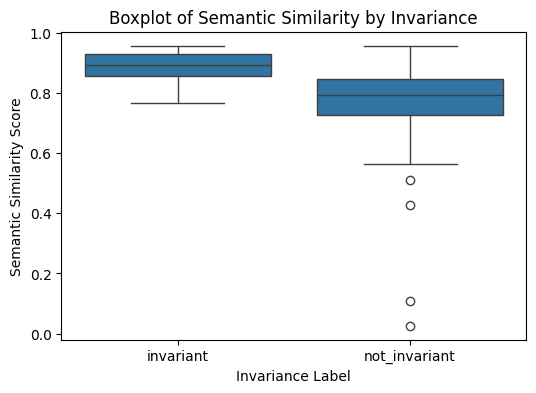

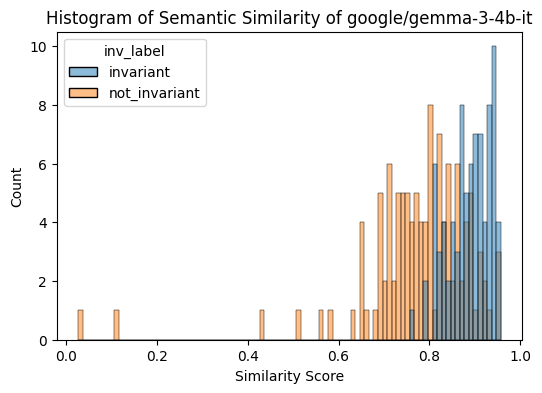

Student's t-test: t=8.5678, p=1.1502e-14
Mann-Whitney U test: U=8150.0000, p=1.3070e-16


/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


threshold, f1, precision, recall
Best thresholds by F1: [(0.80749595, 0.7641509433962264, 0.6328125, 0.9642857142857143), (0.80621433, 0.7605633802816901, 0.627906976744186, 0.9642857142857143), (0.8105252, 0.7582938388625592, 0.6299212598425197, 0.9523809523809523)]
Best thresholds by Macro F1: [(0.84426105, 0.7720039717901062, 0.7720840913685061, 0.7786749482401656), (0.8395975, 0.767144892144892, 0.7677308547181249, 0.7743271221532091), (0.84427047, 0.7667176350662588, 0.7664340614886731, 0.7727225672877847)]

=== Analyzing model_id: google/gemma-3-12b-it ===



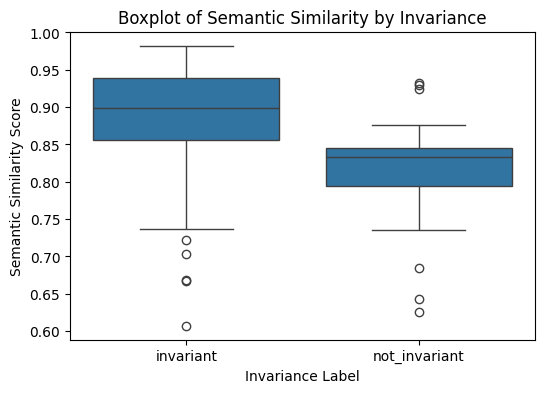

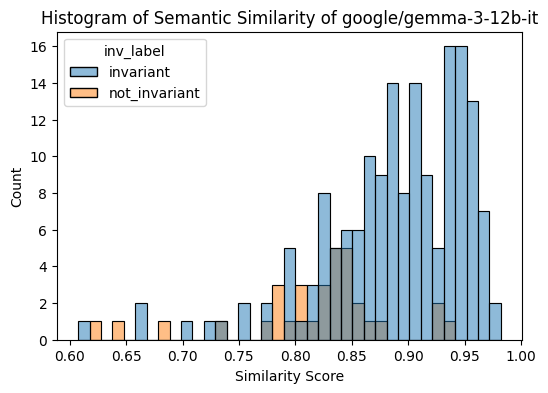

Student's t-test: t=5.4842, p=1.9138e-06
Mann-Whitney U test: U=4453.0000, p=2.3308e-08


/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


threshold, f1, precision, recall
Best thresholds by F1: [(0.6666529, 0.9120879120879121, 0.8426395939086294, 0.9940119760479041), (0.60752344, 0.9100817438692098, 0.835, 1.0), (0.6428456, 0.9095890410958903, 0.8383838383838383, 0.9940119760479041)]
Best thresholds by Macro F1: [(0.849838, 0.6984649122807017, 0.6808017610937318, 0.7831609508256214), (0.8557551, 0.6973285958678773, 0.6838145812589889, 0.8014879332244602), (0.8519587, 0.6937838113708278, 0.6773897058823529, 0.7801669388495736)]

=== Analyzing model_id: mistralai/Mistral-7B-Instruct-v0.2 ===



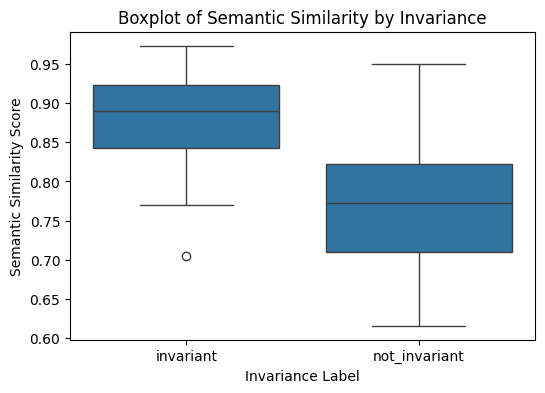

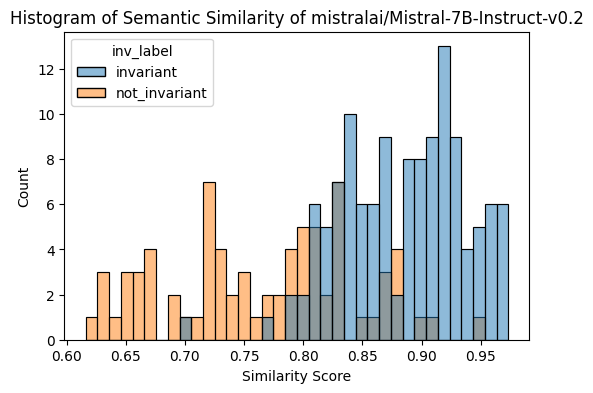

Student's t-test: t=11.5420, p=9.0822e-21
Mann-Whitney U test: U=8370.0000, p=1.5198e-20


/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


threshold, f1, precision, recall
Best thresholds by F1: [(0.8005413, 0.8897058823529412, 0.8231292517006803, 0.968), (0.8075675, 0.8880597014925373, 0.8321678321678322, 0.952), (0.80002785, 0.8864468864468864, 0.8175675675675675, 0.968)]
Best thresholds by Macro F1: [(0.8075675, 0.830393487109905, 0.8634523371365477, 0.8160000000000001), (0.8005413, 0.8276654411764706, 0.8738287767937364, 0.8106666666666666), (0.8084905, 0.8254062121596125, 0.8551481301602719, 0.812)]


In [14]:
labelled_csv = "/homes/lst20/fyp/prompts_labelled_.csv"
labelled_df_ = pd.read_csv(labelled_csv)

labelled_df_.loc[(labelled_df_['is_valid']==False) & (labelled_df_['is_inv'].isna()), 'is_inv'] = "n"
for model in labelled_df_['model_id'].dropna().unique():
    print(f"\n=== Analyzing model_id: {model} ===\n")
    
    model_df = labelled_df_[labelled_df_['model_id'] == model]
    
    if model_df.empty:
        print(f"⚠️ No data for model_id = {model}")
        continue
    
    try:
        analyze_semantic_similarity(model_df, model)
    except Exception as e:
        print(f"❌ Error analyzing model_id {model}: {e}")


In [ ]:
# macro f1
threshold = {"google/gemma-3-4b-it": 0.844, "google/gemma-3-12b-it": , "mistralai/Mistral-7B-Instruct-v0.2": 0.800}
for model in labelled_df_valid['model_id'].dropna().unique():
    print(f"\n=== Analyzing model_id: {model} ===\n")
    
    model_df = labelled_df_valid[labelled_df_valid['model_id'] == model]
    print_confusion(model_df, threshold[model])


=== Analyzing model_id: google/gemma-3-4b-it ===


Confusion Matrix:
        Pred n  Pred y
True n      86      29
True y      16      68

=== Analyzing model_id: google/gemma-3-12b-it ===


Confusion Matrix:
        Pred n  Pred y
True n      26       7
True y      37     130

=== Analyzing model_id: mistralai/Mistral-7B-Instruct-v0.2 ===


Confusion Matrix:
        Pred n  Pred y
True n       5       4
True y       4     121


In [25]:
from sentence_transformers import SentenceTransformer, util
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_self_bleu(prompts):
    smoother = SmoothingFunction().method1
    scores = []
    for i, hyp in enumerate(prompts):
        refs = prompts[:i] + prompts[i+1:]
        # Skip if hyp is empty or if all refs are empty
        if not hyp.strip() or all(not r.strip() for r in refs):
            scores.append(0.0)
            continue
        # Tokenize
        tokenized_refs = [r.split() for r in refs if r.strip()]
        tokenized_hyp = hyp.split()
        # Skip if tokenized result is still empty
        if not tokenized_hyp or not tokenized_refs:
            scores.append(0.0)
            continue
        # Compute BLEU
        score = sentence_bleu(tokenized_refs, tokenized_hyp, smoothing_function=smoother)
        scores.append(score)
    return scores


In [ ]:
labelled_df_ = labelled_df_.reset_index(drop=True)
from statistics import mean

# within each model, get a 0-based counter for each row, then integer-divide by 20
labelled_df_['question_index'] = (labelled_df_
    .groupby('model_id')
    .cumcount()      # 0,1,2,… within each model
    .floordiv(20)    # 20 rows per question → 0,0,…,0,1,1,…,1,2,2…
    .astype(int)
)

grouped = (
    labelled_df_
    .groupby(['model_id', 'question_index'])['text']
    .apply(list)
    .reset_index(name='prompts')
)

# 2) Compute Self-BLEU on each list of prompts
grouped['bleu_score'] = grouped['prompts'].apply(compute_self_bleu)

# 3) Select just model, question_index, and the BLEU score
result = grouped[['model_id', 'question_index', 'bleu_score']]

models = result['model_id'].unique()
pos    = {m: i for i, m in enumerate(models)}

plt.figure(figsize=(8, 5))

# 2. Loop over each unique model
for m in models:
    scores = list(map(lambda x: mean(x),result.loc[result['model_id'] == m, 'bleu_score'].values))
    mean_score = mean(scores)
    # build an array of the SAME length as scores, all equal to pos[m]
    x = np.repeat(pos[m], len(scores))  
    # scatter
    plt.scatter(x, scores, label=m, alpha=0.7)
    plt.hlines(mean_score, x.min() - 0.2, x.max() + 0.2, colors='red', linestyles='dashed')

# 3. Tidy up axes and legend
plt.xticks(list(pos.values()), list(pos.keys()), fontsize=, rotation=45)
plt.xlabel('Model')
plt.ylabel('self-BLEU Score')
plt.title('self-BLEU Scores by Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

TypeError: Fraction.__new__() got an unexpected keyword argument '_normalize'

TypeError: Fraction.__new__() got an unexpected keyword argument '_normalize'

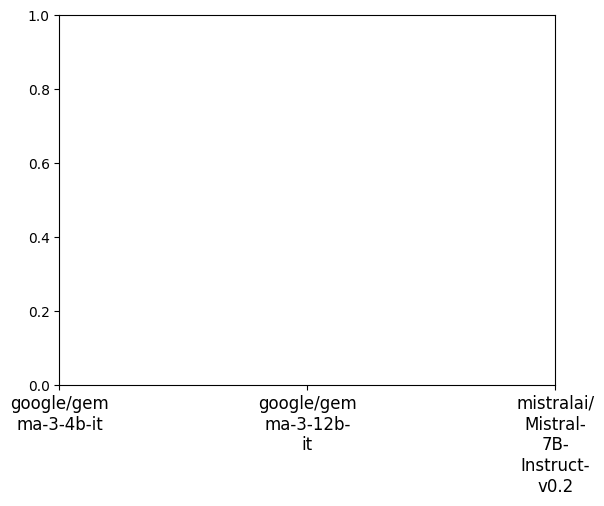

In [19]:
from statistics import mean
import textwrap

labels = labelled_df_['model_id'].unique().tolist()  # replace 'some_column' with the actual label column
pos = {label: i for i, label in enumerate(labels)}
wrapped_labels = [textwrap.fill(label, width=10) for label in pos.keys()]
plt.xticks(list(pos.values()), wrapped_labels, fontsize=12, rotation=0)

plt.xticks(list(pos.values()), wrapped_labels, fontsize=12, rotation=0)

# within each model, get a 0-based counter for each row, then integer-divide by 20
labelled_df_['question_index'] = (labelled_df_
    .groupby('model_id')
    .cumcount()      # 0,1,2,… within each model
    .floordiv(20)    # 20 rows per question → 0,0,…,0,1,1,…,1,2,2…
    .astype(int)
)

grouped = (
    labelled_df_
    .groupby(['model_id', 'question_index'])['text']
    .apply(list)
    .reset_index(name='prompts')
)

# 2) Compute Self-BLEU on each list of prompts
grouped['bleu_score'] = grouped['prompts'].apply(compute_self_bleu)

# 3) Select just model, question_index, and the BLEU score
result = grouped[['model_id', 'question_index', 'bleu_score']]

models = result['model_id'].unique()
pos    = {m: i for i, m in enumerate(models)}

plt.figure(figsize=(8, 5))

# 2. Loop over each unique model
for m in models:
    scores = list(map(lambda x: mean(x),result.loc[result['model_id'] == m, 'bleu_score'].values))
    mean_score = mean(scores)
    # build an array of the SAME length as scores, all equal to pos[m]
    x = np.repeat(pos[m], len(scores))  
    # scatter
    plt.scatter(x, scores, label=m, alpha=0.7)
    plt.hlines(mean_score, x.min() - 0.2, x.max() + 0.2, colors='red', linestyles='dashed')

# 3. Tidy up axes and legend
plt.xticks(list(pos.values()), wrapped_labels, fontsize=12)
plt.xlabel('Model')
plt.ylabel('self-BLEU Score')
plt.title('self-BLEU Scores by Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import math

In [43]:
def compare_lists_with_tolerance(list1, list2, tolerance=0.01):
    for i, (a, b) in enumerate(zip(list1, list2)):
        if not math.isclose(a, b, abs_tol=tolerance):
            print(f"Difference at index {i}: {a} vs {b}")
        else:
            print("same")
            
DF_LOCATION = "/vol/bitbucket/lst20/lex-eval_dataset/PopQA/test.csv"
popqa_df = pd.read_csv(DF_LOCATION)

size = 310
size_ratio = 310 / len(popqa_df) 
# Split the data to get a subset with the same distribution of classes
_, df, _, _ = train_test_split(
    popqa_df,
    popqa_df["prop"],
    test_size=size_ratio,
    shuffle=True,
    random_state=42,
    stratify=popqa_df["prop"]
)

df.columns

Index(['id', 'subj', 'prop', 'obj', 'subj_id', 'prop_id', 'obj_id',
       's_aliases', 'o_aliases', 's_uri', 'o_uri', 's_wiki_title',
       'o_wiki_title', 's_pop', 'o_pop', 'question', 'possible_answers'],
      dtype='object')